In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from neurora.rsa_plot import plot_rdm
from neurora.stats_cal import permutation_test
#from neurora.rdm_cal import bhv_rdm

In [34]:
# --- 文件路径配置 ---
HUMAN_DATA_FILE = 'D:\\HuaweiMoveData\\Users\\黄奕\\Desktop\\Archive of OSF Storage\\my\\data_1\\dim_rel_scaled.csv'
MODEL_DATA_FILE = './modern_bert_embedding_data_base/MASK_encoder_layer11.csv'

# --- 加载人类数据 ---
try:
    human_df = pd.read_csv(HUMAN_DATA_FILE)
except FileNotFoundError:
    print(f"错误：找不到人类数据文件 '{HUMAN_DATA_FILE}'。")
    exit()

# --- 加载模型数据 ---
try:
    model_df = pd.read_csv(MODEL_DATA_FILE)
except FileNotFoundError:
    print(f"错误：找不到模型数据文件 '{MODEL_DATA_FILE}'。")
    exit()



In [35]:
# --- 数据对齐 ---
labels_list = human_df.iloc[:, 0].tolist()
model_df = model_df.set_index(model_df.columns[0]).reindex(labels_list).reset_index()

if not human_df.iloc[:, 0].equals(model_df.iloc[:, 0]):
    print("严重错误：数据对齐失败！")
    exit()

print(f"数据加载与对齐成功！共处理 {len(labels_list)} 个关系。")

# --- 缺失值处理 ---
# 检查数值列（排除第0列标签）并用该列均值填充NA
human_df.iloc[:, 1:] = human_df.iloc[:, 1:].fillna(human_df.iloc[:, 1:].mean())
model_df.iloc[:, 1:] = model_df.iloc[:, 1:].fillna(model_df.iloc[:, 1:].mean())

# --- 提取纯数值数据 ---
human_data = human_df.iloc[:, 1:].values  # (142, 33)
model_data = model_df.iloc[:, 1:].values  # (142, 768)

print(f"人类数据形状: {human_data.shape}")
print(f"模型数据形状: {model_data.shape}")


数据加载与对齐成功！共处理 127 个关系。
人类数据形状: (127, 33)
模型数据形状: (127, 768)


In [36]:
# =============================================================================
# Step 2: 手动计算 RDM（表征相异矩阵）
# =============================================================================
def compute_rdm(data, metric='correlation'):
    """
    计算表征相异矩阵 (Representational Dissimilarity Matrix)
    
    参数:
        data: numpy array, shape (n_conditions, n_features)
              每一行代表一个条件（如一个关系词）的表征向量
        metric: str, 距离度量方式
                'correlation' - 使用 1 - 皮尔逊相关系数
                'euclidean' - 使用欧氏距离
                'cosine' - 使用余弦距离
    
    返回:
        rdm: numpy array, shape (n_conditions, n_conditions)
             对称的相异矩阵
    """
    # pdist 计算所有行对之间的距离，返回压缩形式（下三角）
    distances = pdist(data, metric=metric)
    # squareform 将压缩形式转换为完整的方阵
    rdm = squareform(distances)
    return rdm

# 计算两个 RDM
print("\n正在计算 RDM...")
rdm_human = compute_rdm(human_data, metric='correlation')
rdm_model = compute_rdm(model_data, metric='correlation')

print(f"人类RDM形状: {rdm_human.shape}")
print(f"模型RDM形状: {rdm_model.shape}")


正在计算 RDM...
人类RDM形状: (127, 127)
模型RDM形状: (127, 127)


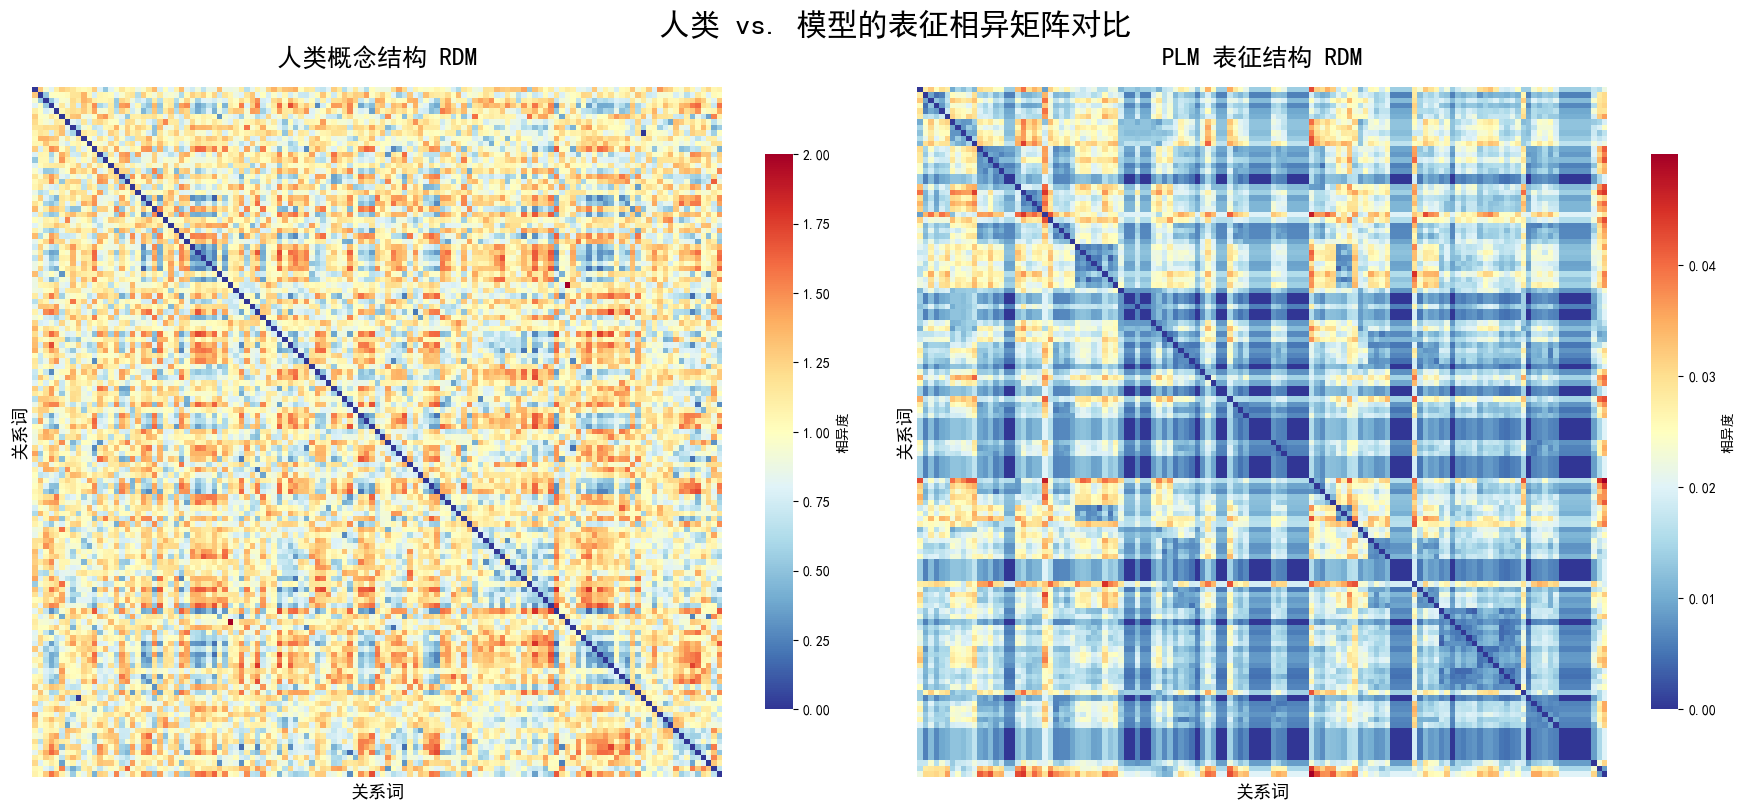

RDM可视化完成。


In [37]:
# =============================================================================
# Step 3: 可视化RDM
# =============================================================================
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- 绘制人类 RDM ---
sns.heatmap(rdm_human, 
            cmap='RdYlBu_r',  # 红-黄-蓝配色
            square=True,      # 保持方形
            cbar_kws={'label': '相异度', 'shrink': 0.8},
            xticklabels=False,  # 由于有142个标签，隐藏x轴标签
            yticklabels=False,  # 隐藏y轴标签
            ax=axes[0])
axes[0].set_title('人类概念结构 RDM', fontsize=18, fontweight='bold', pad=15)
axes[0].set_xlabel('关系词', fontsize=13)
axes[0].set_ylabel('关系词', fontsize=13)

# --- 绘制模型 RDM ---
sns.heatmap(rdm_model, 
            cmap='RdYlBu_r',
            square=True,
            cbar_kws={'label': '相异度', 'shrink': 0.8},
            xticklabels=False,
            yticklabels=False,
            ax=axes[1])
axes[1].set_title('PLM 表征结构 RDM', fontsize=18, fontweight='bold', pad=15)
axes[1].set_xlabel('关系词', fontsize=13)
axes[1].set_ylabel('关系词', fontsize=13)

plt.suptitle('人类 vs. 模型的表征相异矩阵对比', fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("RDM可视化完成。")

In [38]:
# =============================================================================
# Step 4: 计算 RDM 间的 Spearman 相关性
# =============================================================================
def get_rdm_vector(rdm):
    """提取 RDM 的下三角向量（不含对角线）用于相关分析"""
    n = rdm.shape[0]
    tril_indices = np.tril_indices(n, k=-1)
    return rdm[tril_indices]

# 提取下三角向量
human_rdm_vec = get_rdm_vector(rdm_human)
model_rdm_vec = get_rdm_vector(rdm_model)

# 计算 Spearman 相关
rsa_r, rsa_p_simple = spearmanr(human_rdm_vec, model_rdm_vec)

print("\n--- RSA 相关性分析结果 ---")
print(f"模型RDM与人类RDM的Spearman相关系数 (r): {rsa_r:.4f}")
print(f"简单P值: {rsa_p_simple:.6f}")



--- RSA 相关性分析结果 ---
模型RDM与人类RDM的Spearman相关系数 (r): 0.0655
简单P值: 0.000000


In [39]:
# =============================================================================
# Step 5: 置换检验（获取更可靠的p值）
# =============================================================================
def rsa_permutation_test_manual(rdm1, rdm2, n_perm=5000):
    """
    手动实现 RSA 置换检验
    
    原理：在零假设（两个RDM无关）下，打乱其中一个RDM的行列顺序，
         重新计算相关系数，重复多次构建零分布。
    """
    # 计算真实相关系数
    vec1 = get_rdm_vector(rdm1)
    vec2 = get_rdm_vector(rdm2)
    true_r, _ = spearmanr(vec1, vec2)
    
    # 进行置换
    n_conditions = rdm1.shape[0]
    perm_rs = []
    
    print(f"正在执行 {n_perm} 次置换检验...")
    for i in range(n_perm):
        if (i + 1) % 1000 == 0:
            print(f"  进度: {i + 1}/{n_perm}")
        
        # 随机打乱索引
        perm_indices = np.random.permutation(n_conditions)
        # 对 rdm2 进行行列同时置换
        rdm2_perm = rdm2[perm_indices, :][:, perm_indices]
        
        # 计算置换后的相关系数
        vec2_perm = get_rdm_vector(rdm2_perm)
        perm_r, _ = spearmanr(vec1, vec2_perm)
        perm_rs.append(perm_r)
    
    # 计算 p 值：真实r在零分布中的位置
    perm_rs = np.array(perm_rs)
    p_value = np.sum(np.abs(perm_rs) >= np.abs(true_r)) / n_perm
    
    return p_value

p_permutation = rsa_permutation_test_manual(rdm_human, rdm_model, n_perm=5000)

print("\n--- RSA 置换检验结果 ---")
print(f"模型RDM与人类RDM的Spearman相关系数 (r): {rsa_r:.4f}")
print(f"基于 5000 次置换的P值: {p_permutation:.6f}")

if p_permutation < 0.05:
    print("\n✓ 结论：结果显著！PLM的表征结构与人类的概念结构在统计上显著相关。")
else:
    print("\n✗ 结论：结果不显著。未找到PLM与人类表征结构相关的证据。")


正在执行 5000 次置换检验...
  进度: 1000/5000
  进度: 2000/5000
  进度: 3000/5000
  进度: 4000/5000
  进度: 5000/5000

--- RSA 置换检验结果 ---
模型RDM与人类RDM的Spearman相关系数 (r): 0.0655
基于 5000 次置换的P值: 0.000000

✓ 结论：结果显著！PLM的表征结构与人类的概念结构在统计上显著相关。


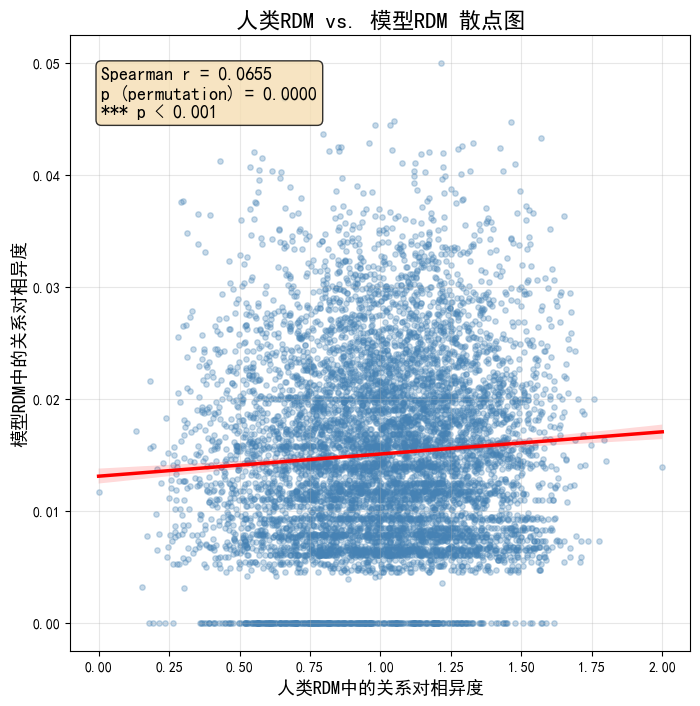


全部分析流程已完成！


In [40]:
# =============================================================================
# Step 6: 可视化RSA结果（散点图）
# =============================================================================
plt.figure(figsize=(8, 8))
sns.regplot(x=human_rdm_vec, y=model_rdm_vec, 
            scatter_kws={'alpha':0.3, 's':15, 'color':'steelblue'}, 
            line_kws={'color':'red', 'linewidth':2.5})

plt.title('人类RDM vs. 模型RDM 散点图', fontsize=16, fontweight='bold')
plt.xlabel('人类RDM中的关系对相异度', fontsize=13)
plt.ylabel('模型RDM中的关系对相异度', fontsize=13)
plt.grid(True, alpha=0.3)

# 添加结果文本框
result_text = f'Spearman r = {rsa_r:.4f}\np (permutation) = {p_permutation:.4f}'
if p_permutation < 0.001:
    result_text += '\n*** p < 0.001'
elif p_permutation < 0.01:
    result_text += '\n** p < 0.01'
elif p_permutation < 0.05:
    result_text += '\n* p < 0.05'

plt.text(0.05, 0.95, result_text,
         transform=plt.gca().transAxes, fontsize=13,
         verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.show()

print("\n全部分析流程已完成！")
